# Google Stock Price Prediction using RNN (LSTM)
**Problem Statement:** Design a time series analysis and prediction system using RNN on the Google stock prices dataset.

In [1]:
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout,SimpleRNN

In [2]:
# Load dataset
df = pd.read_csv('goog.csv')

data = df['Open'].values
data = data.reshape(-1,1)

In [3]:
# Feature Scaling (RNNs are sensitive to scale)
sc = MinMaxScaler(feature_range=(0, 1))
scaled_data = sc.fit_transform(data)

In [4]:
# Creating a data structure with 10 timesteps 
X = []
y = []

for i in range(10, len(scaled_data)):
    X.append(scaled_data[i-10:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

In [5]:
# Reshaping to [samples, timesteps, features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [6]:
# Building the RNN (LSTM)
model = Sequential()

model.add(SimpleRNN(50, return_sequences=True, input_shape=(60,1)))
model.add(SimpleRNN(50))
model.add(Dense(1))

d:\BE\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
# Compile and Train
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.fit(X, y, epochs=100, batch_size=32)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.1264
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0708
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0408
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0395
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0228
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0336
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0238
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0247
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0237
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0172
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0200
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0160
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0141
Epoch 14/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0151
Epoch 15/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0129
Epoch 16/100
2/2 ━━

In [ ]:
# Predicting and Visualizing
predicted = model.predict(X)

predicted = sc.inverse_transform(predicted)

# y is now scaled, so we inverse it here
real = sc.inverse_transform(y)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step


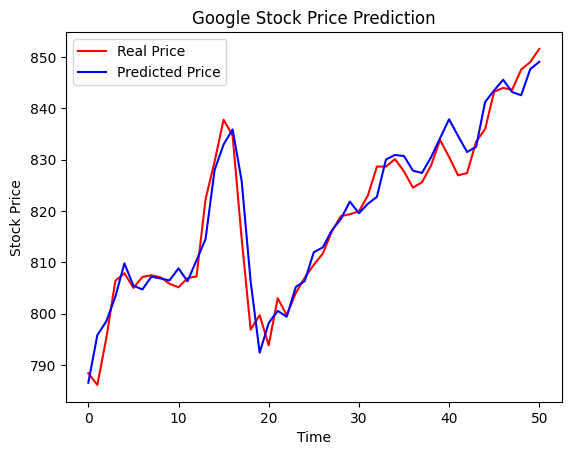

In [13]:
plt.plot(real, color='red', label='Real Price')

plt.plot(predicted.flatten(), color='blue', label='Predicted Price')

plt.title('Google Stock Price Prediction')

plt.xlabel('Time')

plt.ylabel('Stock Price')

plt.legend()

plt.show()

In [11]:
# matrix
